# Explore dataset + MaskCollator

Pulls a shard from R2, wires up `make_dataset` + `MaskCollator` through a `DataLoader`, and visualizes a batch with the encoder/predictor masks overlaid on the video patch grid.

In [1]:
import os
import tempfile
from pathlib import Path

import boto3
import matplotlib.pyplot as plt
import numpy as np
import torch
from dotenv import load_dotenv
from torch.utils.data import DataLoader

from agent_1.data.dataset import make_dataset
from agent_1.models.vjepa.mask import MaskCollator

load_dotenv()

True

In [2]:
BUCKET_NAME = "datasets"
PREFIX = "vision_encoder/DMG/longplays/"

# Clip dims from agent_1/data/dataset.py docstring: (T=16, C=1, H=160, W=144).
# Patch grid below assumes tubelet_size=2, patch_size=(16, 16) -> (8, 10, 9) = 720 patches.
T, C, H, W = 16, 1, 160, 144
TUBELET, PATCH = 2, 16
GRID = (T // TUBELET, H // PATCH, W // PATCH)
BATCH_SIZE = 4

MASK_CONFIGS = [
    {"grid_size": GRID, "mask_area_ratio": 0.4, "mask_ar_range": (0.75, 1.5), "num_sub_masks": 2},
    {"grid_size": GRID, "mask_area_ratio": 0.15, "mask_ar_range": (0.75, 1.5), "num_sub_masks": 1},
]
GRID, BATCH_SIZE

((8, 10, 9), 4)

In [3]:
s3 = boto3.client(
    "s3",
    endpoint_url=os.environ["R2_ENDPOINT_URL"],
    aws_access_key_id=os.environ["R2_ACCESS_KEY_ID"],
    aws_secret_access_key=os.environ["R2_SECRET_ACCESS_KEY"],
)

resp = s3.list_objects_v2(Bucket=BUCKET_NAME, Prefix=PREFIX, MaxKeys=1)
shard_key = resp["Contents"][0]["Key"]

tmp = tempfile.NamedTemporaryFile(suffix=".tar", delete=False)
s3.download_file(BUCKET_NAME, shard_key, tmp.name)
shard_path = Path(tmp.name)
print(f"{shard_key} -> {shard_path}")

vision_encoder/DMG/longplays/000000.tar -> /var/folders/st/4tnj9mbs1_z44dqyd8cyxnt00000gn/T/tmp7u57mz_v.tar


In [4]:
dataset = make_dataset(str(shard_path), shuffle_buffer=0, shardshuffle=False)
collator = MaskCollator(MASK_CONFIGS)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, collate_fn=collator)

batch = next(iter(loader))
print("video:", batch["video"].shape, batch["video"].dtype)
for i, (me, mp) in enumerate(zip(batch["masks_enc"], batch["masks_pred"])):
    print(f"cfg {i}: masks_enc {tuple(me.shape)}  masks_pred {tuple(mp.shape)}")
print("clips:", list(zip(batch["source_video"], batch["clip_number"].tolist())))

video: torch.Size([4, 16, 1, 144, 160]) torch.uint8
cfg 0: masks_enc (4, 280)  masks_pred (4, 360)
cfg 1: masks_enc (4, 592)  masks_pred (4, 128)
clips: [('Pokémon_Red', 101846), ('Donkey_Kong_Land_III', 403), ('The_Final_Fantasy_Legend', 3047), ("Kirby's_Block_Ball", 1008)]


## Visualize a batch

Each `MaskGenerator` returns flat indices into a `(T_p, H_p, W_p)` patch grid. To overlay them on pixels we reshape the indices to a 3D boolean grid, upsample to pixel resolution by repeating each patch `tubelet x patch x patch` times, and tint kept patches green / masked-out patches red.

In [5]:
def patch_mask_to_pixel(indices_1d: torch.Tensor, value: int) -> np.ndarray:
    """Scatter flat patch indices into a (T, H, W) uint8 mask at pixel resolution."""
    grid = torch.zeros(GRID[0] * GRID[1] * GRID[2], dtype=torch.uint8)
    grid[indices_1d] = value
    grid = grid.view(GRID)
    grid = grid.repeat_interleave(TUBELET, 0).repeat_interleave(PATCH, 1).repeat_interleave(PATCH, 2)
    return grid.numpy()


def overlay_clip(video: torch.Tensor, m_enc: torch.Tensor, m_pred: torch.Tensor, title: str) -> None:
    """Render every frame of one clip with encoder (green) and predictor (red) regions."""
    enc = patch_mask_to_pixel(m_enc, 1)
    pred = patch_mask_to_pixel(m_pred, 1)
    frames = video.squeeze(1).to(torch.float32).numpy() / 255.0

    fig, axes = plt.subplots(2, T // 2, figsize=(T, 4))
    fig.suptitle(title, fontsize=12)
    for i, ax in enumerate(axes.flat):
        rgb = np.stack([frames[i]] * 3, axis=-1)
        rgb[enc[i] == 1] = 0.5 * rgb[enc[i] == 1] + 0.5 * np.array([0.2, 0.8, 0.2])
        rgb[pred[i] == 1] = 0.5 * rgb[pred[i] == 1] + 0.5 * np.array([0.9, 0.2, 0.2])
        ax.imshow(np.clip(rgb, 0, 1))
        ax.set_title(f"f{i}", fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

IndexError: boolean index did not match indexed array along axis 0; size of axis is 144 but size of corresponding boolean axis is 160

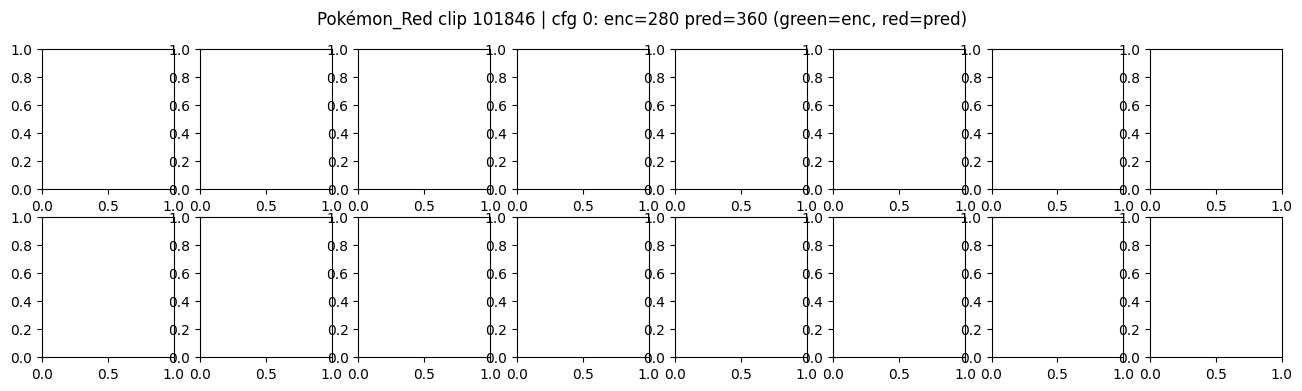

In [6]:
# For each sample in the batch, show its frames overlaid with the first mask config's enc/pred regions.
cfg_idx = 0
for b in range(batch["video"].shape[0]):
    title = (
        f"{batch['source_video'][b]} clip {batch['clip_number'][b].item()} "
        f"| cfg {cfg_idx}: enc={batch['masks_enc'][cfg_idx][b].numel()} "
        f"pred={batch['masks_pred'][cfg_idx][b].numel()} (green=enc, red=pred)"
    )
    overlay_clip(
        batch["video"][b],
        batch["masks_enc"][cfg_idx][b],
        batch["masks_pred"][cfg_idx][b],
        title,
    )

In [ ]:
# Compare both mask configs on a single clip side by side.
b = 0
for cfg_idx in range(len(MASK_CONFIGS)):
    cfg = MASK_CONFIGS[cfg_idx]
    title = (
        f"cfg {cfg_idx}: area={cfg['mask_area_ratio']} sub_masks={cfg['num_sub_masks']} "
        f"-> enc={batch['masks_enc'][cfg_idx][b].numel()} pred={batch['masks_pred'][cfg_idx][b].numel()}"
    )
    overlay_clip(
        batch["video"][b],
        batch["masks_enc"][cfg_idx][b],
        batch["masks_pred"][cfg_idx][b],
        title,
    )

In [ ]:
shard_path.unlink(missing_ok=True)